In [34]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from xgboost import XGBClassifier
from pulseiq.ml_logic.registry import save_model, load_model
from pulseiq.ml_logic.train import train_model


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
#!wget 'https://data.mendeley.com/datasets/m8cgwxs9s6/2/files/4c109a9f-2462-4dce-b93c-5789168c5401'

In [36]:
#!unzip raw_data/example.zip

In [37]:
path = "/home/candelaneumann/code/CandeNeu/pulseIQ/raw_data/DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv"
df = pd.read_csv(path)
df.head()

,age,gender,pulse_rate,systolic_bp,diastolic_bp,glucose,height,weight,bmi,family_diabetes,hypertensive,family_hypertension,cardiovascular_disease,stroke,diabetic
0,42,Female,66,110,73,5.88,1.65,70.2,25.75,0,0,0,0,0,No
1,35,Female,60,125,68,5.71,1.47,42.5,19.58,0,0,0,0,0,No
2,62,Female,57,127,74,6.85,1.52,47.0,20.24,0,0,0,0,0,No
3,73,Male,55,193,112,6.28,1.63,57.4,21.72,0,0,0,0,0,No
4,68,Female,71,150,81,5.71,1.42,36.0,17.79,0,0,0,0,0,No


In [38]:
df1 = df.copy()

In [39]:
'''
Droping the ID columns
'''

df1 = df.drop(columns=['systolic_bp', 'diastolic_bp', 'family_diabetes', 'family_hypertension', 'glucose', 'stroke'])

In [40]:
df1.head(2)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,Female,66,1.65,70.2,25.75,0,0,No
1,35,Female,60,1.47,42.5,19.58,0,0,No


In [41]:
'''
Binaryzing Diabetes to 0 = Normal and 1 = Diabetes
'''

map_diabetes = {
    'No': 0,
    'Yes': 1
}

df1['diabetic'] = df1['diabetic'].map(map_diabetes)

In [42]:
'''
Binaryzing Sex to 0 = Female and 1 = Male
'''

map_sex = {
    'Female': 0,
    'Male': 1
}

df1['gender'] = df1['gender'].map(map_sex)

In [43]:
df1.head(4)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,0,66,1.65,70.2,25.75,0,0,0
1,35,0,60,1.47,42.5,19.58,0,0,0
2,62,0,57,1.52,47.0,20.24,0,0,0
3,73,1,55,1.63,57.4,21.72,0,0,0


In [44]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5288 non-null   int64  
 1   gender                  5288 non-null   int64  
 2   pulse_rate              5288 non-null   int64  
 3   height                  5288 non-null   float64
 4   weight                  5288 non-null   float64
 5   bmi                     5288 non-null   float64
 6   hypertensive            5288 non-null   int64  
 7   cardiovascular_disease  5288 non-null   int64  
 8   diabetic                5288 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 371.9 KB


In [45]:
df1.head(2)

,age,gender,pulse_rate,height,weight,bmi,hypertensive,cardiovascular_disease,diabetic
0,42,0,66,1.65,70.2,25.75,0,0,0
1,35,0,60,1.47,42.5,19.58,0,0,0


In [46]:

'''
Scanling the dataset
'''
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()




X_scaled = scaler.set_output(transform='pandas').fit_transform(df1[['age', 'pulse_rate', 'height', 'weight', 'bmi']])
y_diabetic = df1['diabetic']
y_hypertensive = df1['hypertensive']
y_cv = df1['cardiovascular_disease']


In [47]:
y_diabetic

0       0
1       0
2       0
3       0
4       0
       ..
5283    0
5284    1
5285    0
5286    0
5287    0
Name: diabetic, Length: 5288, dtype: int64

<Axes: >

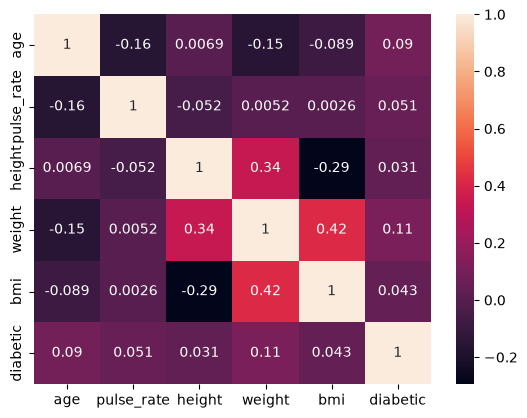

In [48]:
sns.heatmap(pd.concat([X_scaled, y_diabetic], axis=1).corr(), annot=True)

## Logistic Regression baseline

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.multiclass import OneVsRestClassifier

model = LogisticRegression(random_state=42)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_scaled, y_diabetic, train_size=0.7, random_state=42, stratify=y_diabetic)

model.fit(X_train_d, y_train_d)

cv = cross_validate(model, X_train_d, y_train_d, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.683312668902541)

In [50]:
model = LogisticRegression(random_state=42)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_scaled, y_hypertensive, train_size=0.7, random_state=42, stratify=y_hypertensive)

model.fit(X_train_h, y_train_h)

cv = cross_validate(model, X_train_h, y_train_h, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.7366587857844008)

In [51]:
model = LogisticRegression(random_state=42)

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X_scaled, y_cv, train_size=0.7, random_state=42, stratify=y_cv)

model.fit(X_train_cv, y_train_cv)

cv = cross_validate(model, X_train_cv, y_train_cv, cv=5, scoring=['roc_auc'])

cv['test_roc_auc'].mean()

np.float64(0.7298592578472488)

In [52]:
from sklearn.metrics import roc_auc_score
def model_f(y):
    params={
        'n_estimators': 400,
        'max_depth': 6,
        'learning_rate': 0.9964688888846461,
        'min_child_weight': 1, 'subsample': 0.5004689439033313,
        'colsample_bytree': 0.7613304427154312,
        'gamma': 0.054181861010946, 'reg_alpha': 0.05914008164898518,
        'reg_lambda': 1.1933199710131277e-06
    }
    model_xgb = XGBClassifier(**params)

    model_xgb.fit(X_scaled, y)

    cv_xgb = cross_validate(model_xgb, X_scaled, y, cv=5, scoring=['roc_auc'])

    skf = StratifiedKFold(n_splits=5)
    skf.get_n_splits()

    scores = []

    for i, (train_index, test_index) in enumerate(skf.split(X_scaled, y)):
        X_train = X_scaled.iloc[train_index]
        y_train = y.iloc[train_index]
        X_test = X_scaled.iloc[test_index]
        y_test = y.iloc[test_index]

        model_xgb = XGBClassifier(eval_metric='logloss')

        model_xgb.fit(X_train, y_train)

        y_pred = model_xgb.predict_proba(X_test)[:, 1]


        scores.append(roc_auc_score(y_test, y_pred))
    return np.mean(scores)

In [53]:
scores_d = model_f(y_diabetic)
scores_h = model_f(y_hypertensive)
scores_cv = model_f(y_cv)

In [54]:
scores_d, scores_h, scores_cv

(np.float64(0.6603345635857357),
 np.float64(0.7026213661682676),
 np.float64(0.6345794032709098))

In [55]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = X_scaled
y = y_diabetic

def objective(trial):
    # clasificador
    classifier_name = trial.suggest_categorical('classifier', ['XGBClassifier']) #, 'LogisticRegression', 'RandomForestClassifier'

    if classifier_name == 'XGBClassifier':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'eval_metric': 'logloss',
            'random_state': 42,
            'n_jobs': -1
        }

    #elif classifier_name == 'LogisticRegression':
    #    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])
    #    if solver == 'lbfgs':
    #        penalty = trial.suggest_categorical('penalty_lbfgs', ['l2', None])
    #    elif solver == 'liblinear':
    #        penalty = trial.suggest_categorical('penalty_liblinear', ['l1', 'l2'])
    #    elif solver == 'saga':
    #        penalty = trial.suggest_categorical('penalty_saga', ['l1', 'l2', 'elasticnet', None])

    #    params = {
    #        'solver': solver,
    #        'penalty': penalty,
    #        'C': trial.suggest_float('C', 1e-4, 100.0, log=True),
    #        'max_iter': 2000,
    #        'random_state': 42
    #    }

  #      if penalty == 'elasticnet':
  #          params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

  #  else: # RandomForestClassifier
  #      params = {
  #          'n_estimators': trial.suggest_int('rf_n_estimators', 50, 500, step=50),
  #          'max_depth': trial.suggest_int('rf_max_depth', 3, 20),
  #          'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
  #          'random_state': 42,
  #          'n_jobs': -1
  #      }

    # Kfolds
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    X_arr = np.array(X_scaled)
    y_arr = np.array(y_diabetic)

    for train_idx, val_idx in skf.split(X_arr, y_arr):
        X_train, X_test = X_arr[train_idx], X_arr[val_idx]
        y_train, y_test = y_arr[train_idx], y_arr[val_idx]

        #if classifier_name == 'XGBClassifier':
        model = XGBClassifier(**params)
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        #elif classifier_name == 'LogisticRegression':
        #    model = LogisticRegression(**params)
        #    model.fit(X_train, y_train)
        #else:
        #    model = RandomForestClassifier(**params)
        #    model.fit(X_train, y_train)

        preds = model.predict_proba(X_test)
        score = roc_auc_score(y_test, preds[:,1])
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Mejor ROC_AUC:", study.best_value)
print("Mejores parámetros:", study.best_params)


[I 2026-08-27 11:50:23,175] A new study created in memory with name: no-name-25a8384e-0d15-4f14-a749-6c3d961b8ad6
[I 2026-08-27 11:50:28,324] Trial 0 finished with value: 0.6420766753542891 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 500, 'max_depth': 9, 'learning_rate': 0.39032039523921763, 'min_child_weight': 8, 'subsample': 0.5756219384536173, 'colsample_bytree': 0.6013677735433753, 'gamma': 4.4821552747709125e-07, 'reg_alpha': 1.732007499709354, 'reg_lambda': 1.6424261247746466e-08}. Best is trial 0 with value: 0.6420766753542891.
[I 2026-08-27 11:50:39,080] Trial 1 finished with value: 0.6495034175694974 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 800, 'max_depth': 10, 'learning_rate': 0.10621920601517562, 'min_child_weight': 6, 'subsample': 0.6907250441139074, 'colsample_bytree': 0.6384028870742923, 'gamma': 5.461650315959151e-06, 'reg_alpha': 7.67933287789496e-06, 'reg_lambda': 0.0026331012394965356}. Best is trial 1 with value: 0.64950341

Mejor ROC_AUC: 0.7159833446267985
Mejores parámetros: {'classifier': 'XGBClassifier', 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.021003002345652538, 'min_child_weight': 10, 'subsample': 0.7462983922960696, 'colsample_bytree': 0.9073816041640297, 'gamma': 0.2058434472691587, 'reg_alpha': 0.00011330484084728366, 'reg_lambda': 0.03345964069199756}


In [58]:
params = {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.015564492219614985, 'min_child_weight': 2, 'subsample': 0.9138162118797337, 'colsample_bytree': 0.8710949067499039, 'gamma': 0.0002543771303215554, 'reg_alpha': 0.5293237315244861, 'reg_lambda': 1.8913627848034716e-08}
model_t = train_model(XGBClassifier, X_scaled, y_diabetic, params)
save_model(model_t, 'diabetic')


(PosixPath('/home/candelaneumann/code/CandeNeu/pulseIQ/frontend/XGBoost_diabetic.json'),
 PosixPath('/home/candelaneumann/code/CandeNeu/pulseIQ/frontend/config_diabetic.json'))

In [64]:
model_d = load_model('diabetic')

prediction = model_d.predict(X_test_d)

prediction.mean()

np.float64(0.000630119722747322)